# AI Translation Pipeline — Multi-Language Round-Trip
Loads 5000 rows from `syvai/finetranslations-chat-da`, round-trip translates English → X → English for 5 target languages (Spanish, Korean, Chinese, Swahili, Maltese), scores quality with BLEU / chrF / BERTScore, and compares across languages.

## Data

Streams 5000 rows from [`syvai/finetranslations-chat-da`](https://huggingface.co/datasets/syvai/finetranslations-chat-da) on HuggingFace. Each row contains a `messages` list with `role`/`content` pairs — we extract only the `user` messages, which are the original English texts. These same source sentences are used as input for all 5 language round-trips.

In [8]:
import sys
!{sys.executable} -m pip install anthropic python-dotenv -q


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import os
import itertools
import pandas as pd
from datasets import load_dataset
from anthropic import Anthropic
from concurrent.futures import ThreadPoolExecutor, as_completed
from dotenv import load_dotenv

load_dotenv()  # loads ANTHROPIC_API_KEY from .env file

client = Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])

# claude-haiku-4-5: cheapest model, strong translation quality
# $0.80/MTok input + $4/MTok output → ~$0.00051/call
# 500 rows × 5 languages × 2 passes = 5,000 calls ≈ $2.55 (well within $5 budget)
MODEL = "claude-haiku-4-5-20251001"
NUM_WORKERS = 5   # Tier 1 rate limit: keep concurrent connections at 5
NUM_ROWS = 500

# Target languages for round-trip translation
LANGUAGES = {
    "Spanish": "es",
    "Korean":  "ko",
    "Chinese": "zh",
    "Swahili": "sw",
    "Maltese": "mt",
}

In [10]:
# Load rows using streaming (avoids downloading the full dataset)
stream = load_dataset("syvai/finetranslations-chat-da", split="train", streaming=True)
df_raw = pd.DataFrame(itertools.islice(stream, NUM_ROWS))

print(df_raw.shape)
print("\nSample row (messages structure):")
print(df_raw["messages"][0])

(500, 1)

Sample row (messages structure):
[{'content': "The Jysk billionaire Lars Larsen has finally been allowed to expand his empire.\nThe Danish Competition and Consumer Authority today approved Larsen's takeover of furniture trading house Actona.\nLars Larsen and Actona completed the deal back in April last year and…\nPhoto: Scanpix\nCompanies By Bjarne Bang\nWould you like to learn more about strategy and leadership? The Børsen Executive Club is back, giving you inspiration and concrete tools. Interested? Click here and read more.", 'role': 'user'}, {'content': 'Jysk-milliardæren Lars Larsen har endelig fåret lov at udvide sit imperium.\nKonkurrence- og Forbrugerstyrelsen har i dag godkendt Larsens overtagelse af møbelhandelshuset Actona.\nLars Larsen og Actona sluttede handelen tilbage i april i fjor og...\nFoto: Scanpix\nVirksomheder Af Bjarne Bang\nVil du blive klogere på strategi og ledelse? Børsen Executive Club er tilbage, og giver dig inspiration og konkrete værktøjer. Int

In [11]:
# Extract English user content from messages into a plain list
def extract_user_content(messages):
    for msg in messages:
        if msg.get("role") == "user":
            return msg["content"]
    return None

english_texts = (
    df_raw["messages"]
    .apply(extract_user_content)
    .dropna()
    .reset_index(drop=True)
    .tolist()
)

print(f"Extracted {len(english_texts)} English source texts")

Extracted 500 English source texts


## Translation

Round-trip translation using Claude (`claude-haiku-4-5`): English → X → English for each of the 5 target languages. Both translation passes are combined into a single worker function and run with 20 parallel workers per language. Per-language results are saved to `lang_results/` as they complete (so a crash mid-run can be resumed), then concatenated into `translations.csv`.

In [ ]:
import threading
import time
from collections import deque

class TierOneLimiter:
    """
    Enforces Anthropic Tier 1 rate limits simultaneously:
      - RPM  : max 45 requests/min  (hard limit: 50)
      - OTPM : max 9,000 output tokens/min  (hard limit: 10,000)

    Before each call: reserves `max_tokens` pessimistically so the window
    never exceeds the limit even in the worst case.
    After each call: replaces the reservation with the real token count so
    later calls benefit from any headroom that opens up.
    """
    def __init__(self, max_rpm=45, max_otpm=9000):
        self._lock = threading.Lock()
        self._calls = deque()      # call timestamps
        self._tokens = deque()     # (timestamp, output_tokens)
        self._max_rpm = max_rpm
        self._max_otpm = max_otpm

    def _clean(self, now):
        while self._calls and now - self._calls[0] >= 60:
            self._calls.popleft()
        while self._tokens and now - self._tokens[0][0] >= 60:
            self._tokens.popleft()

    def before_call(self, reserved):
        """Block until both limits have room, then register the call."""
        while True:
            with self._lock:
                now = time.time()
                self._clean(now)
                used = sum(t for _, t in self._tokens)
                if len(self._calls) < self._max_rpm and used + reserved <= self._max_otpm:
                    self._calls.append(now)
                    self._tokens.append((now, reserved))
                    return
            time.sleep(0.5)

    def after_call(self, reserved, actual):
        """Replace the pessimistic reservation with the real output token count."""
        with self._lock:
            entries = list(self._tokens)
            for i in range(len(entries) - 1, -1, -1):
                if entries[i][1] == reserved:
                    entries[i] = (entries[i][0], actual)
                    break
            self._tokens = deque(entries)

limiter = TierOneLimiter(max_rpm=45, max_otpm=9000)
MAX_TOKENS = 512  # cap per response; news snippets are well under this

# Translation helper (Anthropic API)
def translate(text, source_lang, target_lang):
    limiter.before_call(MAX_TOKENS)
    message = client.messages.create(
        model=MODEL,
        max_tokens=MAX_TOKENS,
        temperature=0.1,
        system=(
            f"You are a professional translator. "
            f"Translate the following text from {source_lang} to {target_lang}. "
            f"Return only the translated text, nothing else."
        ),
        messages=[{"role": "user", "content": text}]
    )
    limiter.after_call(MAX_TOKENS, message.usage.output_tokens)
    return message.content[0].text

In [13]:
# Combined round-trip worker: EN → target_lang → EN
def translate_round_trip(args):
    i, text, language = args
    translated = translate(text, "English", language)
    back = translate(translated, language, "English")
    print(f"[{language}][{i+1}/{len(english_texts)}] EN: {text[:60]!r}")
    print(f"  → {language}: {translated[:60]!r}")
    print(f"  → EN: {back[:60]!r}\n")
    return i, translated, back

In [14]:
import os as _os
_os.makedirs("lang_results", exist_ok=True)

all_results = []

for language in LANGUAGES:
    out_path = f"lang_results/{language.lower()}.csv"

    # Resume support: skip if this language was already translated
    if _os.path.exists(out_path):
        print(f"Skipping {language} — loading {out_path}")
        all_results.append(pd.read_csv(out_path))
        continue

    print(f"\n{'='*60}")
    print(f"Translating EN → {language} → EN  ({len(english_texts)} rows)")
    print(f"{'='*60}\n")

    translated_col = [None] * len(english_texts)
    back_col       = [None] * len(english_texts)

    with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
        futures = {
            executor.submit(translate_round_trip, (i, text, language)): i
            for i, text in enumerate(english_texts)
        }
        for future in as_completed(futures):
            i, translated, back = future.result()
            translated_col[i] = translated
            back_col[i]       = back

    lang_df = pd.DataFrame({
        "english_original": english_texts,
        "language":         language,
        "translated":       translated_col,
        "back_translated":  back_col,
    })
    lang_df.to_csv(out_path, index=False)
    all_results.append(lang_df)
    print(f"{language} complete — {lang_df['translated'].notna().sum()} rows translated")

df = pd.concat(all_results, ignore_index=True)
print(f"\nTotal rows: {len(df)}")
print(df["language"].value_counts())
df.head(10)


Translating EN → Spanish → EN  (500 rows)

[Spanish][4/500] EN: 'fyens.dk uses cookies to give you a good experience and to c'
  → Spanish: 'fyens.dk utiliza cookies para ofrecerle una buena experienci'
  → EN: 'fyens.dk uses cookies to offer you a good experience and col'

[Spanish][5/500] EN: "THE NEWSPAPER\nMorgan Motor Company is the world's oldest exi"
  → Spanish: 'EL PERIÓDICO\nMorgan Motor Company es la marca de automóviles'
  → EN: 'THE NEWSPAPER\nMorgan Motor Company is the oldest privately o'

[Spanish][1/500] EN: 'The Jysk billionaire Lars Larsen has finally been allowed to'
  → Spanish: 'El multimillonario juto Lars Larsen finalmente ha sido autor'
  → EN: 'The billionaire Jysk Lars Larsen has finally been authorized'

[Spanish][3/500] EN: 'Funhouse Katsuragawa\nFunhouse Katsuragawa offers rooms with '
  → Spanish: 'Funhouse Katsuragawa\nFunhouse Katsuragawa ofrece habitacione'
  → EN: 'Funhouse Katsuragawa\n\nFunhouse Katsuragawa offers air-condit'

[Spanish][2/500] EN: 

,english_original,language,translated,back_translated
0,The Jysk billionaire Lars Larsen has finally b...,Spanish,El multimillonario juto Lars Larsen finalmente...,The billionaire Jysk Lars Larsen has finally b...
1,I need my hedge trimmed in my allotment garden...,Spanish,Necesito que corten mi seto en mi huerto en Ba...,I need you to cut my hedge in my garden in Bal...
2,Funhouse Katsuragawa\nFunhouse Katsuragawa off...,Spanish,Funhouse Katsuragawa\nFunhouse Katsuragawa ofr...,Funhouse Katsuragawa\n\nFunhouse Katsuragawa o...
3,fyens.dk uses cookies to give you a good exper...,Spanish,fyens.dk utiliza cookies para ofrecerle una bu...,fyens.dk uses cookies to offer you a good expe...
4,THE NEWSPAPER\nMorgan Motor Company is the wor...,Spanish,EL PERIÓDICO\nMorgan Motor Company es la marca...,THE NEWSPAPER\nMorgan Motor Company is the old...
5,This luxurious mansion is situated surrounded ...,Spanish,Esta lujosa mansión se encuentra rodeada de am...,This luxurious mansion is surrounded by extens...
6,For travelers who want to experience the sight...,Spanish,Para los viajeros que desean experimentar la v...,For travelers who wish to experience the sight...
7,With a convenient location in Cavaion Veronese...,Spanish,Con una ubicación conveniente en Cavaion Veron...,With a convenient location in Cavaion Veronese...
8,Lamps and Lanterns\nTo get the most out of you...,Spanish,Lámparas y Faroles\nPara aprovechar al máximo ...,Lamps and Lanterns\nTo make the most of your n...
9,Quiet location below the vineyards. The center...,Spanish,Ubicación tranquila bajo los viñedos. El centr...,# Quiet location beneath the vineyards. Würzbu...


In [15]:
# Save raw translations (before scoring) — analysis section can be re-run from here
df.to_csv("translations.csv", index=False)
print(f"Saved {len(df)} rows to translations.csv")
df.head()

Saved 2500 rows to translations.csv


,english_original,language,translated,back_translated
0,The Jysk billionaire Lars Larsen has finally b...,Spanish,El multimillonario juto Lars Larsen finalmente...,The billionaire Jysk Lars Larsen has finally b...
1,I need my hedge trimmed in my allotment garden...,Spanish,Necesito que corten mi seto en mi huerto en Ba...,I need you to cut my hedge in my garden in Bal...
2,Funhouse Katsuragawa\nFunhouse Katsuragawa off...,Spanish,Funhouse Katsuragawa\nFunhouse Katsuragawa ofr...,Funhouse Katsuragawa\n\nFunhouse Katsuragawa o...
3,fyens.dk uses cookies to give you a good exper...,Spanish,fyens.dk utiliza cookies para ofrecerle una bu...,fyens.dk uses cookies to offer you a good expe...
4,THE NEWSPAPER\nMorgan Motor Company is the wor...,Spanish,EL PERIÓDICO\nMorgan Motor Company es la marca...,THE NEWSPAPER\nMorgan Motor Company is the old...


## Analysis

Compares `english_original` against `back_translated` using three complementary metrics:

- **BLEU** — word n-gram overlap (0–100). Good baseline but sensitive to text length.
- **chrF** — character n-gram F-score (0–100). More robust to paraphrasing and length variation.
- **BERTScore** — semantic similarity via RoBERTa embeddings (0–1). Captures meaning even when wording differs.

Scores are computed per language group and compared across all 5 languages.

> Start here if you only want to re-run the analysis without repeating the translations.

In [16]:
# Load translations from CSV — start here to re-run analysis without repeating API calls
df = pd.read_csv("translations.csv")
print(f"Loaded {len(df)} rows across {df['language'].nunique()} languages")
print(df["language"].value_counts())
df.head()

Loaded 2500 rows across 5 languages
language
Spanish    500
Korean     500
Chinese    500
Swahili    500
Maltese    500
Name: count, dtype: int64


,english_original,language,translated,back_translated
0,The Jysk billionaire Lars Larsen has finally b...,Spanish,El multimillonario juto Lars Larsen finalmente...,The billionaire Jysk Lars Larsen has finally b...
1,I need my hedge trimmed in my allotment garden...,Spanish,Necesito que corten mi seto en mi huerto en Ba...,I need you to cut my hedge in my garden in Bal...
2,Funhouse Katsuragawa\nFunhouse Katsuragawa off...,Spanish,Funhouse Katsuragawa\nFunhouse Katsuragawa ofr...,Funhouse Katsuragawa\n\nFunhouse Katsuragawa o...
3,fyens.dk uses cookies to give you a good exper...,Spanish,fyens.dk utiliza cookies para ofrecerle una bu...,fyens.dk uses cookies to offer you a good expe...
4,THE NEWSPAPER\nMorgan Motor Company is the wor...,Spanish,EL PERIÓDICO\nMorgan Motor Company es la marca...,THE NEWSPAPER\nMorgan Motor Company is the old...


In [17]:
import sys
!{sys.executable} -m pip install sacrebleu bert-score matplotlib seaborn -q


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import sacrebleu
from bert_score import score as bert_score

# Sentence-level BLEU and chrF (row-by-row)
df["bleu"] = df.apply(
    lambda r: sacrebleu.sentence_bleu(r["back_translated"], [r["english_original"]]).score, axis=1
)
df["chrf"] = df.apply(
    lambda r: sacrebleu.sentence_chrf(r["back_translated"], [r["english_original"]]).score, axis=1
)

# BERTScore — batched per language (lang="en" because we score EN back-translations vs EN originals)
bert_p_all = pd.Series(index=df.index, dtype=float)
bert_r_all = pd.Series(index=df.index, dtype=float)
bert_f_all = pd.Series(index=df.index, dtype=float)

for language, group in df.groupby("language"):
    print(f"BERTScore: {language} ({len(group)} rows)...")
    P, R, F1 = bert_score(
        group["back_translated"].tolist(),
        group["english_original"].tolist(),
        lang="en", verbose=False
    )
    bert_p_all.loc[group.index] = P.numpy()
    bert_r_all.loc[group.index] = R.numpy()
    bert_f_all.loc[group.index] = F1.numpy()

df["bertscore_precision"] = bert_p_all
df["bertscore_recall"]    = bert_r_all
df["bertscore_f1"]        = bert_f_all

# Summary table
summary = df.groupby("language")[["bleu", "chrf", "bertscore_f1"]].mean().round(3)
print("\n=== Mean scores per language ===")
print(summary.to_string())

BERTScore: Chinese (500 rows)...


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 6891.39it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTScore: Korean (500 rows)...


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 21375.40it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTScore: Maltese (500 rows)...


...

BERTScore: Spanish (500 rows)...


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 22081.56it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTScore: Swahili (500 rows)...


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 21914.87it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



=== Mean scores per language ===
            bleu    chrf  bertscore_f1
language                              
Chinese   31.471  60.092         0.927
Korean    29.071  55.929         0.924
Maltese   46.179  64.801         0.935
Spanish   57.449  74.903         0.958
Swahili   39.191  60.530         0.931


In [19]:
# Save full results including scores
df.to_csv("translations.csv", index=False)
print(f"Saved {len(df)} rows to translations.csv")
df[["language", "english_original", "back_translated", "bleu", "chrf", "bertscore_f1"]].head(10)

Saved 2500 rows to translations.csv


,language,english_original,back_translated,bleu,chrf,bertscore_f1
0,Spanish,The Jysk billionaire Lars Larsen has finally b...,The billionaire Jysk Lars Larsen has finally b...,73.179935,86.212147,0.986692
1,Spanish,I need my hedge trimmed in my allotment garden...,I need you to cut my hedge in my garden in Bal...,46.263481,67.779161,0.960623
2,Spanish,Funhouse Katsuragawa\nFunhouse Katsuragawa off...,Funhouse Katsuragawa\n\nFunhouse Katsuragawa o...,66.068627,83.586272,0.966523
3,Spanish,fyens.dk uses cookies to give you a good exper...,fyens.dk uses cookies to offer you a good expe...,61.772750,80.834513,0.962072
4,Spanish,THE NEWSPAPER\nMorgan Motor Company is the wor...,THE NEWSPAPER\nMorgan Motor Company is the old...,60.435474,82.116811,0.982147
5,Spanish,This luxurious mansion is situated surrounded ...,This luxurious mansion is surrounded by extens...,65.617814,81.511493,0.969068
6,Spanish,For travelers who want to experience the sight...,For travelers who wish to experience the sight...,77.689667,91.079679,0.978731
7,Spanish,With a convenient location in Cavaion Veronese...,With a convenient location in Cavaion Veronese...,88.002205,93.844340,0.986050
8,Spanish,Lamps and Lanterns\nTo get the most out of you...,Lamps and Lanterns\nTo make the most of your n...,70.749512,81.539964,0.987508
9,Spanish,Quiet location below the vineyards. The center...,# Quiet location beneath the vineyards. Würzbu...,63.282320,82.119640,0.962432


## Visualisation

Five-panel plot comparing translation quality across all 5 languages:
- **Row 1**: Distribution of BLEU, chrF, and BERTScore F1 per language (box plots with annotated means)
- **Row 2**: Normalized mean scores per language (bar chart), and chrF vs BERTScore F1 scatter coloured by language

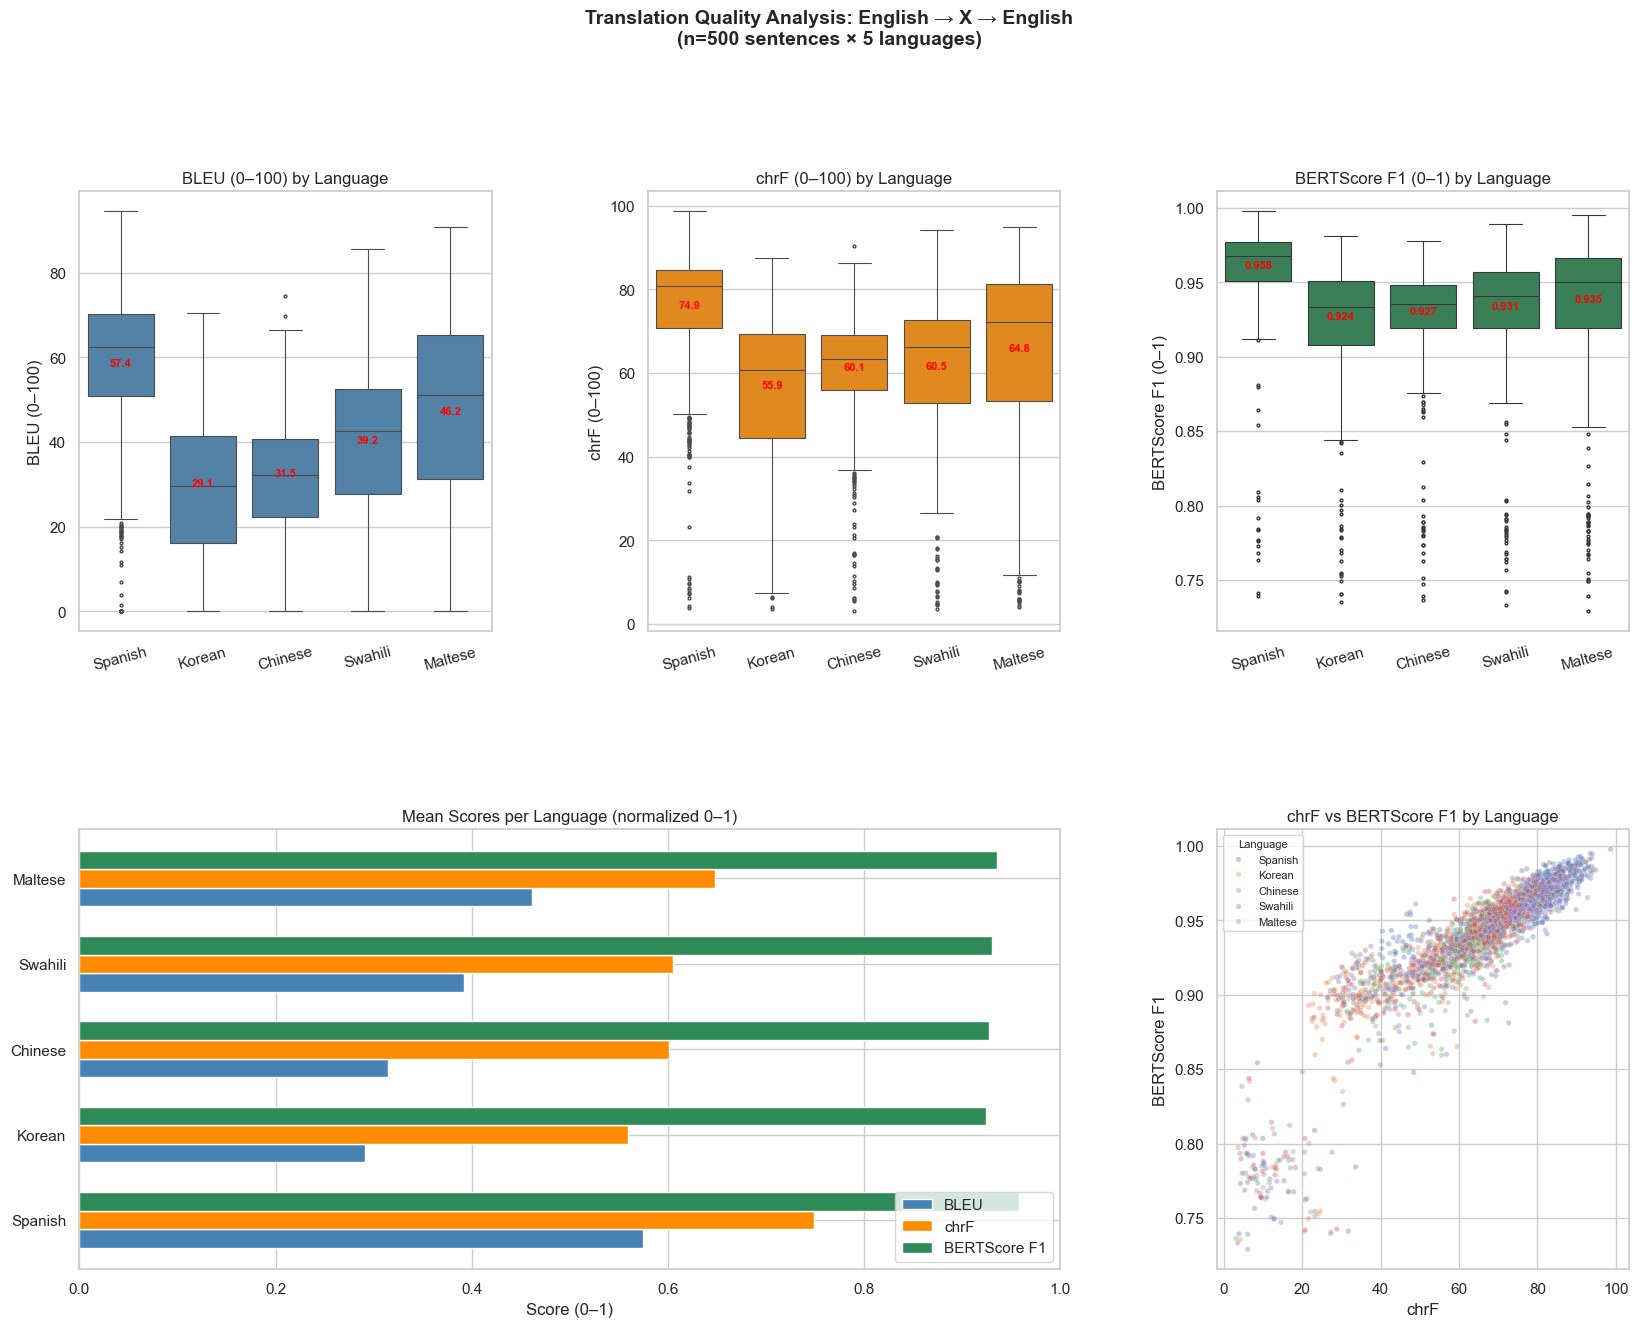

Saved to translation_quality.png


In [20]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style="whitegrid")
LANGUAGE_ORDER = list(LANGUAGES.keys())

fig = plt.figure(figsize=(20, 14))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

METRICS = [
    ("bleu",         "BLEU (0–100)",       "steelblue"),
    ("chrf",         "chrF (0–100)",        "darkorange"),
    ("bertscore_f1", "BERTScore F1 (0–1)",  "seagreen"),
]

# Row 1: Box plot per metric, language on x-axis
for col, (metric, xlabel, color) in enumerate(METRICS):
    ax = fig.add_subplot(gs[0, col])
    sns.boxplot(
        data=df, x="language", y=metric,
        order=LANGUAGE_ORDER, color=color,
        fliersize=2, linewidth=0.8, ax=ax,
    )
    means = df.groupby("language")[metric].mean()
    fmt = ".1f" if metric != "bertscore_f1" else ".3f"
    for j, lang in enumerate(LANGUAGE_ORDER):
        ax.text(j, means[lang], f"{means[lang]:{fmt}}",
                ha="center", va="bottom", fontsize=8, color="red", fontweight="bold")
    ax.set_title(f"{xlabel} by Language")
    ax.set_xlabel("")
    ax.set_ylabel(xlabel)
    ax.tick_params(axis="x", rotation=15)

# Row 2, col 0-1: Normalized mean scores horizontal bar chart
ax4 = fig.add_subplot(gs[1, 0:2])
means_df = df.groupby("language")[["bleu", "chrf", "bertscore_f1"]].mean()
means_norm = means_df.copy()
means_norm["bleu"] = means_norm["bleu"] / 100
means_norm["chrf"] = means_norm["chrf"] / 100
means_norm = means_norm.loc[LANGUAGE_ORDER]
means_norm.plot(kind="barh", ax=ax4,
                color=["steelblue", "darkorange", "seagreen"],
                width=0.65, edgecolor="white")
ax4.set_title("Mean Scores per Language (normalized 0–1)")
ax4.set_xlabel("Score (0–1)")
ax4.set_ylabel("")
ax4.legend(["BLEU", "chrF", "BERTScore F1"], loc="lower right")
ax4.set_xlim(0, 1)

# Row 2, col 2: chrF vs BERTScore F1 scatter, hue=language
ax5 = fig.add_subplot(gs[1, 2])
sns.scatterplot(
    data=df, x="chrf", y="bertscore_f1",
    hue="language", hue_order=LANGUAGE_ORDER,
    alpha=0.35, s=15, ax=ax5,
)
ax5.set_title("chrF vs BERTScore F1 by Language")
ax5.set_xlabel("chrF")
ax5.set_ylabel("BERTScore F1")
ax5.legend(title="Language", fontsize=8, title_fontsize=8)

n_per_lang = len(df) // len(LANGUAGES)
plt.suptitle(
    f"Translation Quality Analysis: English → X → English\n"
    f"(n={n_per_lang} sentences × {len(LANGUAGES)} languages)",
    fontsize=14, fontweight="bold", y=1.01
)
plt.savefig("translation_quality.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved to translation_quality.png")